In [95]:

from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent

print((ROOT_DIR / 'utils').exists())
print((ROOT_DIR / 'utils' / '__init__.py').exists())




True
True


In [96]:
import utils

print(utils)

<module 'utils' from '/home/luiz.cruz/Documents/projetos_cruz/sctec_dados/modulo1_mini_projeto_avaliativo/utils/__init__.py'>


In [97]:
from utils.config import OUTPUT_DIR

print(OUTPUT_DIR)

/home/luiz.cruz/Documents/projetos_cruz/sctec_dados/modulo1_mini_projeto_avaliativo/outputs


In [98]:
from utils.config import OUTPUT_DIR
import pandas as pd

arquivo = OUTPUT_DIR / 'base_varejo_tratada.csv'

print(arquivo)
print(arquivo.exists())

/home/luiz.cruz/Documents/projetos_cruz/sctec_dados/modulo1_mini_projeto_avaliativo/outputs/base_varejo_tratada.csv
True


In [99]:
from utils.formatacao import padronizar_nome

from utils.limpeza import tratar_falso_nulos


In [100]:
from utils.formatacao import padronizar_nome

In [101]:
from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

In [102]:
arquvivo_limpo = OUTPUT_DIR / 'base_varejo_tratada.csv'
df = pd.read_csv(arquvivo_limpo)

df.head()

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-01-02,1000,534,M,4,1,C,67,Bebidas,Refrigerante Guarana
1,2019-01-02,1040,279,M,1,2,B,38,Alimentos,Leite Condensado
2,2019-01-02,1078,290,F,1,0,B,145,Pet,Racao Umida Para Gatos
3,2019-01-02,1082,323,M,1,3,B,69,Bebidas,Refrigerante Limao
4,2019-01-02,1103,957,M,2,3,B,15,Alimentos,Batata Doce


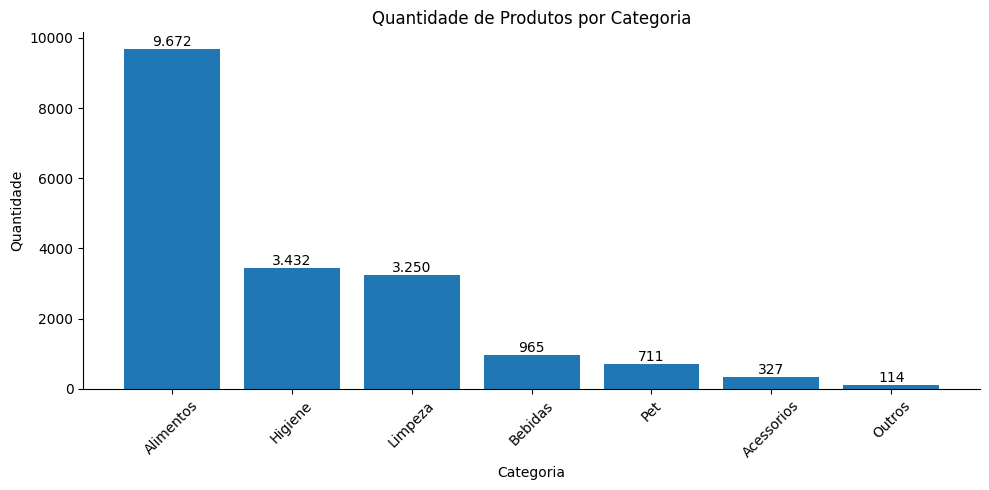

In [ ]:
import matplotlib.pyplot as plt

cat_counts = df["PR_CAT"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

# Aqui barras recebe os objetos retangulo do matplotlib
barras = ax.bar(
    cat_counts.index,
    cat_counts.values
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for barra in barras:
    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{altura:,}".replace(",", "."),
        ha="center",
        va="bottom"
    )

ax.set_title("Quantidade de Produtos por Categoria")
ax.set_xlabel("Categoria")
ax.set_ylabel("Quantidade")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    Path(OUTPUT_DIR) / "grafico_produtos_categoria.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

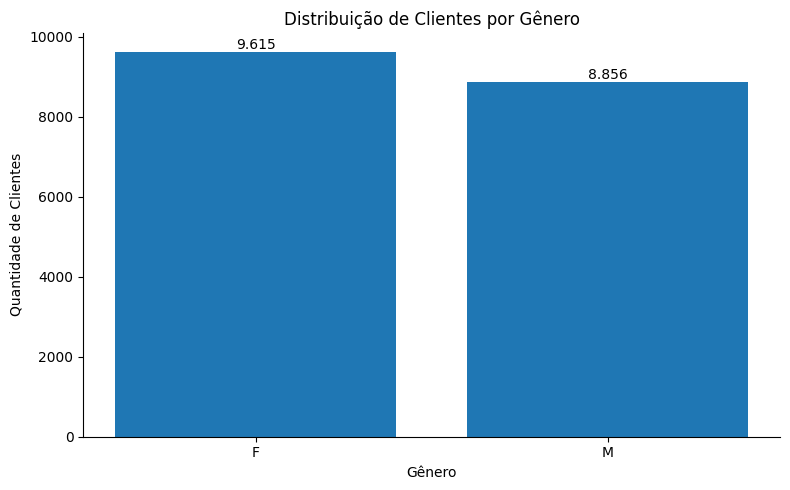

In [104]:
import matplotlib.pyplot as plt

CL_GENERO = df["CL_GENERO"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    CL_GENERO.index,
    CL_GENERO.values
)

# Remover bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adicionar valores
for barra in barras:
    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{altura:,}".replace(",", "."),
        ha="center",
        va="bottom"
    )

ax.set_title("Distribuição de Clientes por Gênero")
ax.set_xlabel("Gênero")
ax.set_ylabel("Quantidade de Clientes")

plt.tight_layout()

plt.savefig(
    Path(OUTPUT_DIR) / 'grafico_clientes_genero.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

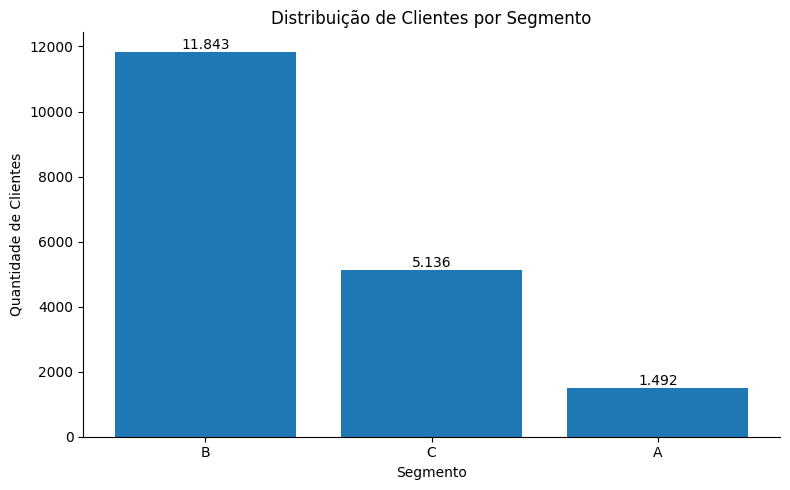

In [105]:
import matplotlib.pyplot as plt

clientes_segmento = df['CL_SEG'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    clientes_segmento.index,
    clientes_segmento.values
)

# Remover bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adicionar valores nas barras
for barra in barras:
    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{int(altura):,}".replace(",", "."),
        ha="center",
        va="bottom"
    )

ax.set_title("Distribuição de Clientes por Segmento")
ax.set_xlabel("Segmento")
ax.set_ylabel("Quantidade de Clientes")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "grafico_clientes_segmento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

PR_NOME
Brocolis                177
Sabonete                177
File De Peixe           177
Removedor               179
Cenoura                 182
Salgadinhos De Milho    184
Detergente              189
Ricota                  190
Mamao Papaya            192
Presunto Cozido         312
Name: count, dtype: int64


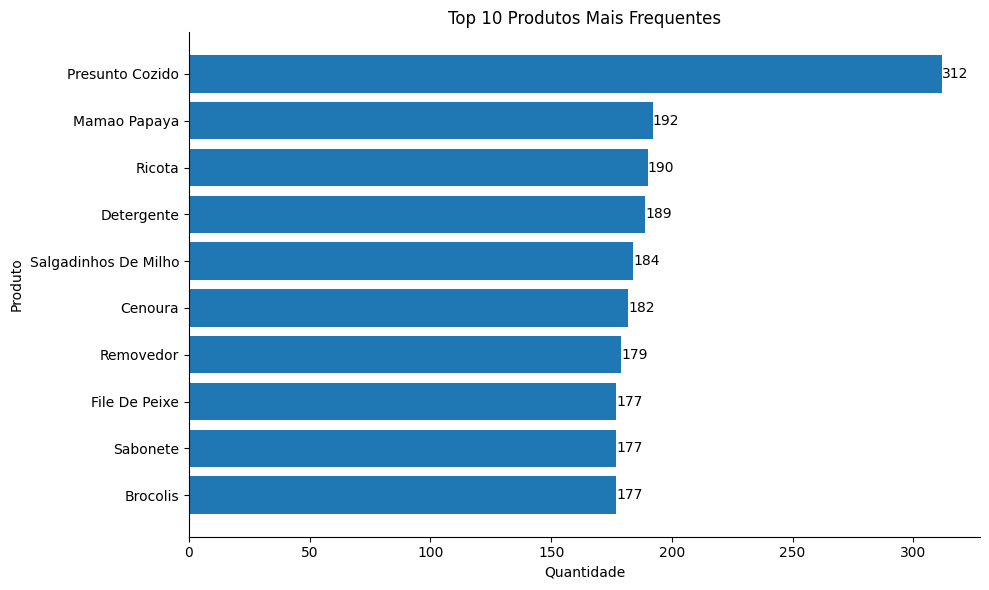

In [ ]:
top_produtos = (
    df["PR_NOME"]
    .value_counts()
    .head(10)
    .sort_values()
)

print(top_produtos)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh(
    top_produtos.index,
    top_produtos.values
)

# Remover bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adicionar valores
for barra in barras:
    largura = barra.get_width()

    ax.text(
        largura,
        barra.get_y() + barra.get_height()/2,
        f"{int(largura):,}".replace(",", "."),
        va="center",
        ha="left"
    )

ax.set_title("Top 10 Produtos Mais Frequentes")
ax.set_xlabel("Quantidade")
ax.set_ylabel("Produto")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "grafico_top10_produtos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

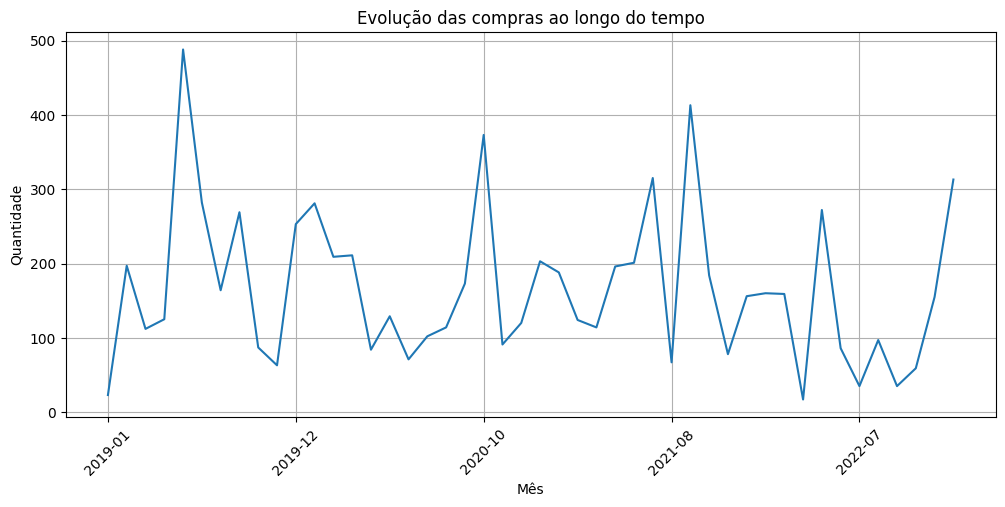

In [115]:
df['DATA'] = pd.to_datetime(df['DATA'], dayfirst=True)

compras_mes = (
    df.groupby(df['DATA'].dt.to_period('M'))
    .size()
)

compras_mes.index = compras_mes.index.astype(str)

plt.figure(figsize=(12, 5))
compras_mes.plot()
plt.title(('Evolução das compras ao longo do tempo'))
plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.grid()

plt.savefig(
    OUTPUT_DIR / 'grafico_compras_evolucao.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()